<a href="https://colab.research.google.com/github/Lavanya-Manila/Lavanya-Manila/blob/main/plant_disease_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow

In [ ]:
!pip install kaggle


In [ ]:
mkdir -p ~/.kaggle && echo KGAT_7fa8701b065f5e59b07732bec74f81ba > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [ ]:
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:07<00:00, 91.7MB/s]



In [ ]:
!unzip plantdisease.zip

Streaming output truncated to the last 5000 lines.
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0922e026-b563-438d-b9ed-74

In [ ]:
#import libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Sequential

In [ ]:
#load dataset
train_dataset = image_dataset_from_directory(
    "/content/PlantVillage",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

validation_dataset = image_dataset_from_directory(
    "/content/PlantVillage",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.


In [ ]:
#explore dataset
class_names = train_dataset.class_names

print(class_names)
print(len(class_names))

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
15


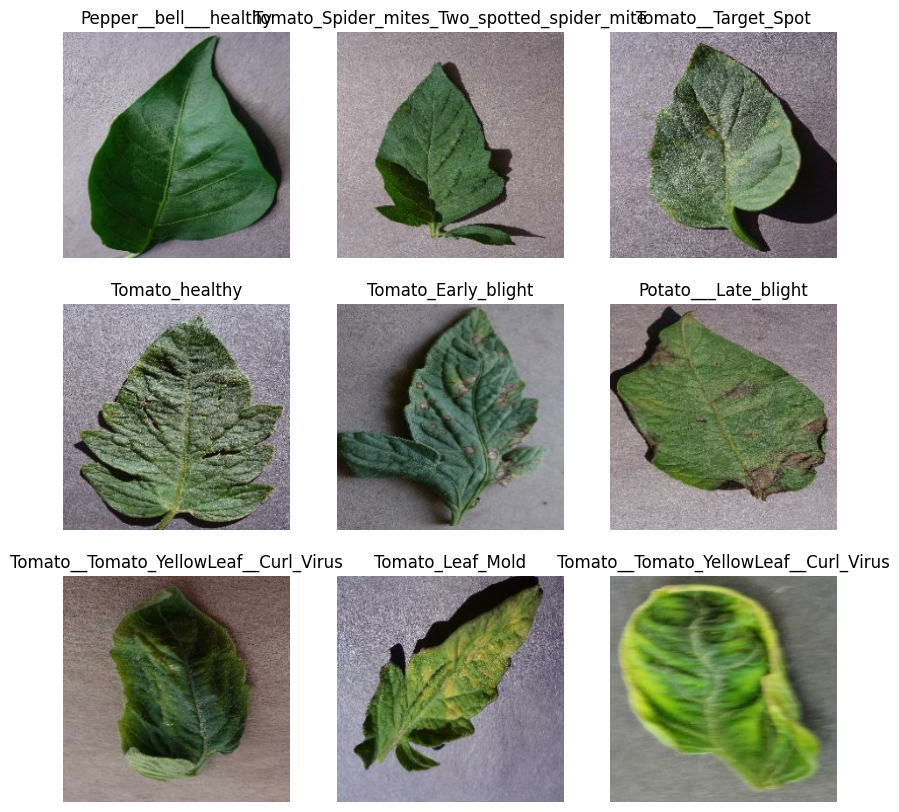

In [ ]:
#display image
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

In [ ]:
#improve performance
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)

validation_dataset = validation_dataset.prefetch(AUTOTUNE)

In [ ]:
#data augmentation
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip(),

    tf.keras.layers.RandomRotation(0.2),

    tf.keras.layers.RandomZoom(0.2),

    tf.keras.layers.RandomContrast(0.2)

])

In [ ]:
#Loading efficientnetB0
base_model = EfficientNetB0(

    include_top=False,

    weights="imagenet",

    input_shape=(224,224,3)

)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#freezing the model
base_model.trainable = False

In [ ]:
#building custom model
model = Sequential([

    data_augmentation,

    base_model,

    GlobalAveragePooling2D(),

    Dropout(0.3),

    Dense(256, activation="relu"),

    Dense(len(class_names), activation="softmax")

])

In [ ]:
#compiling the model
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [ ]:
#training the model
history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=10

)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 956s 2s/step - accuracy: 0.8925 - loss: 0.3092 - val_accuracy: 0.9072 - val_loss: 0.2510
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 929s 2s/step - accuracy: 0.9027 - loss: 0.2850 - val_accuracy: 0.9166 - val_loss: 0.2367
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 975s 2s/step - accuracy: 0.9050 - loss: 0.2743 - val_accuracy: 0.9060 - val_loss: 0.2589
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 968s 2s/step - accuracy: 0.9114 - loss: 0.2591 - val_accuracy: 0.9145 - val_loss: 0.2294
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 979s 2s/step - accuracy: 0.9159 - loss: 0.2415 - val_accuracy: 0.9188 - val_loss: 0.2279
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 1006s 2s/step - accuracy: 0.9173 - loss: 0.2365 - val_accuracy: 0.9256 - val_loss: 0.2048
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 1115s 2s/step - accuracy: 0.9216 - loss: 0.2260 - val_accuracy: 0.9256 - val_loss: 0.2037
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 930s 2s/step - accuracy: 0.9234 - loss: 0.2128 - val_ac

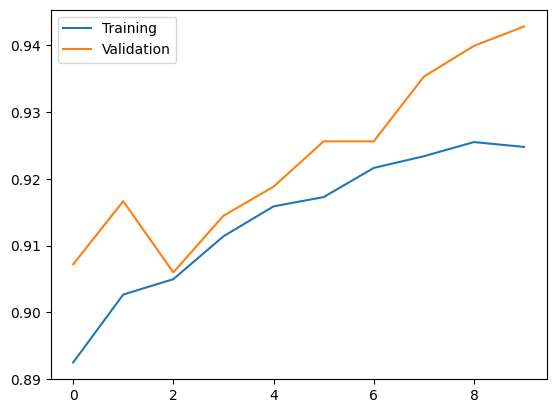

In [ ]:
#accuracy plot
plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.legend(["Training","Validation"])

plt.show()

In [ ]:
model.evaluate(validation_dataset)

129/129 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - accuracy: 0.9428 - loss: 0.1573


[0.1572873294353485, 0.9428156018257141]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
y_true = []
y_pred = []

for images, labels in validation_dataset:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)


In [ ]:
cm = confusion_matrix(y_true, y_pred)

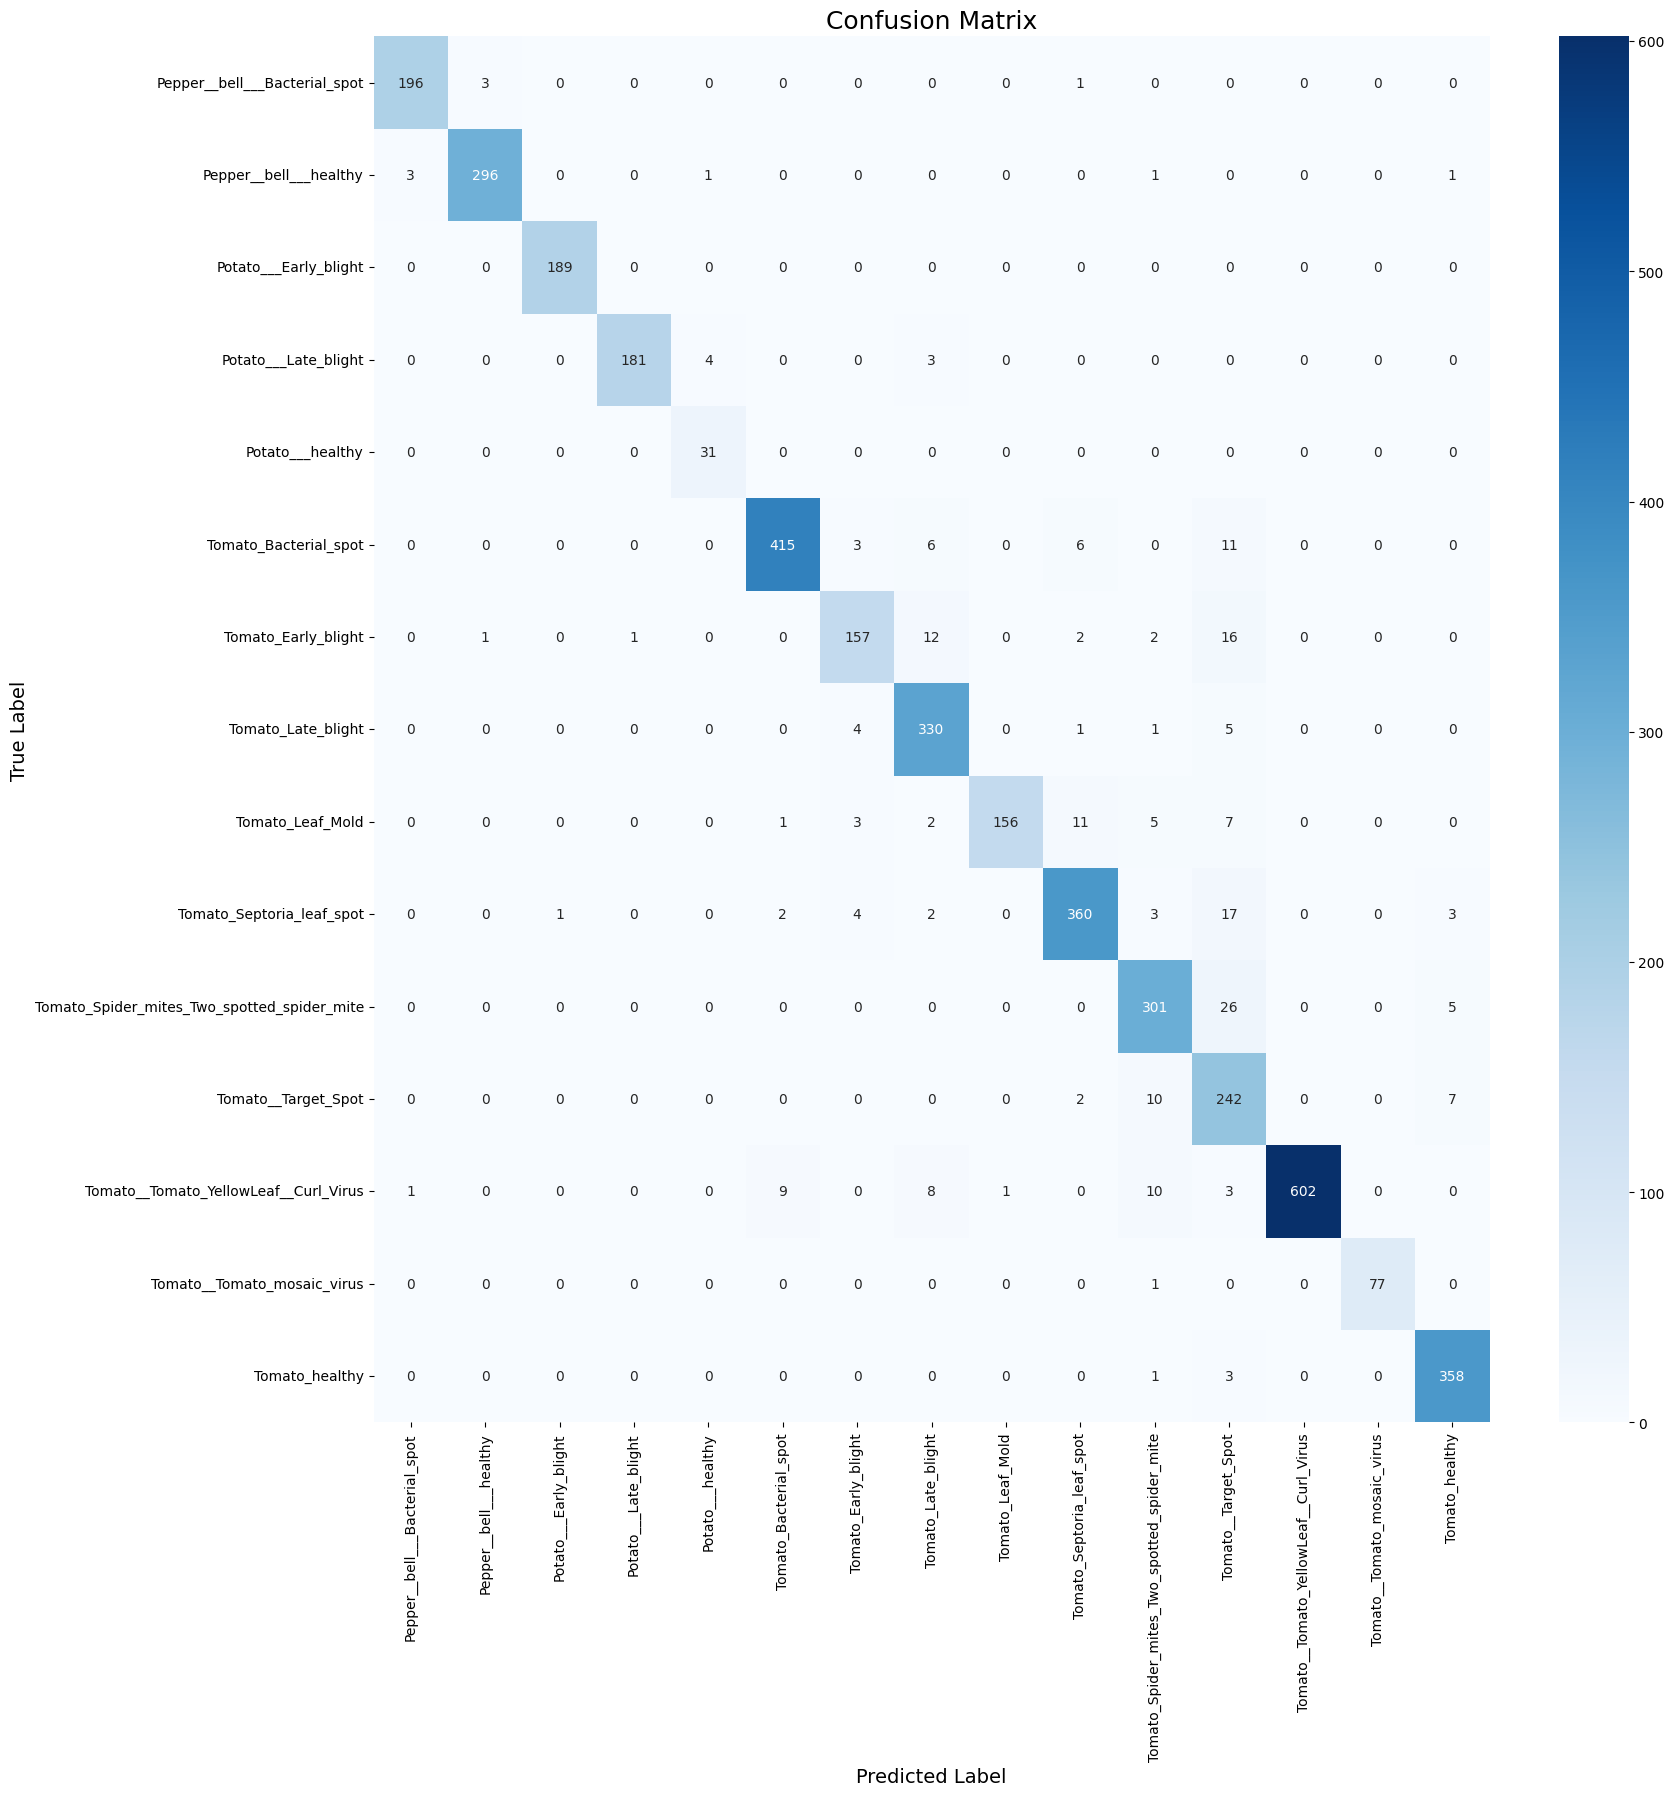

In [ ]:
plt.figure(figsize=(18, 18))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Confusion Matrix", fontsize=18)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.98      0.98      0.98       200
                     Pepper__bell___healthy       0.99      0.98      0.98       302
                      Potato___Early_blight       0.99      1.00      1.00       189
                       Potato___Late_blight       0.99      0.96      0.98       188
                           Potato___healthy       0.86      1.00      0.93        31
                      Tomato_Bacterial_spot       0.97      0.94      0.96       441
                        Tomato_Early_blight       0.92      0.82      0.87       191
                         Tomato_Late_blight       0.91      0.97      0.94       341
                           Tomato_Leaf_Mold       0.99      0.84      0.91       185
                  Tomato_Septoria_leaf_spot       0.94      0.92      0.93       392
Tomato_Spider_mites_Two_spotted_spider_mite       0.90      0.91

In [ ]:
model.save("plant_disease_model.keras")

In [ ]:
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array
import tensorflow as tf
import numpy as np

In [ ]:
uploaded = files.upload()

Saving tomato late blight.webp to tomato late blight.webp


In [ ]:
image_path = list(uploaded.keys())[0]

print("Uploaded Image:", image_path)

Uploaded Image: tomato late blight.webp


In [ ]:
img = load_img(image_path, target_size=(224, 224))

img_array = img_to_array(img)

# Normalize the image (same preprocessing used during training)
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

In [ ]:
prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print(f"Predicted Disease : {predicted_class}")
print(f"Confidence Score  : {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Predicted Disease : Tomato_Late_blight
Confidence Score  : 99.80%


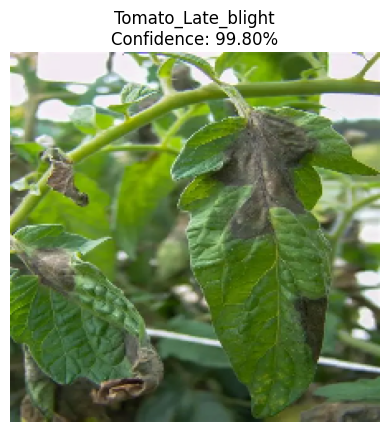

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis("off")
plt.title(f"{predicted_class}\nConfidence: {confidence:.2f}%")
plt.show()